# Linear Regression met SciKit-Learn

We zagen hoe we een zeer eenvoudige beste fit-lijn konden creëren, maar laten we nu ons toolbox aanzienlijk uitbreiden om te beginnen nadenken over de overwegingen van overfitting, underfitting, model-evaluatie, en ook meerdere kenmerken!

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Residuals

### We checken eerst even de residuals voor de **geschikte** dataset:

In [2]:
quartet = pd.read_csv('data/anscombes_quartet1.csv')

We weten dat de regressiefunctie voor elke dataset in anscombes quartes gelijk is aan: y = 3.00 + 0.50x

Uit deze functie kunnen we zowel de voorspelde waarde ŷ als de residuals (y - ŷ) halen:

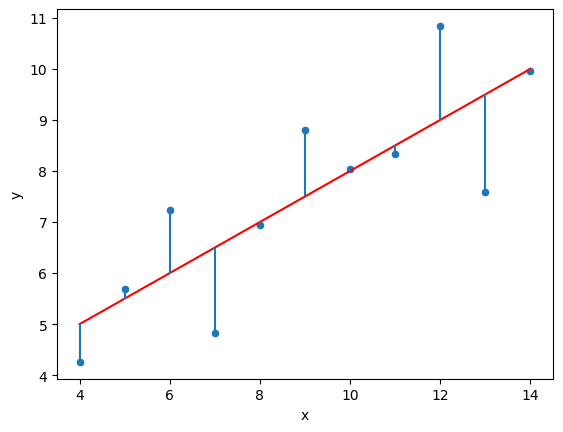

In [ ]:
quartet['pred_y'] = 3 + 0.5 * quartet['x']
quartet['residual'] = quartet['y'] - quartet['pred_y']

# plot de ruwe data
sns.scatterplot(data=quartet, x='x', y='y')
# plot de regressielijn
sns.lineplot(data=quartet, x='x', y='pred_y', color='red')
# plot de verticale lijnen tussen de punten en de regressielijn
plt.vlines(quartet['x'], quartet['y'], quartet['y'] - quartet['residual'])

Check of deze data normaal verdeeld is:

- De sns.kdeplot functie maakt deel uit van de Seaborn-bibliotheek in Python en wordt gebruikt om Kernel Density Estimation (KDE) plots te maken. 
- KDE is een manier om de kansdichtheidsfunctie van een continue willekeurige variabele te schatten. 
- Eenvoudig gezegd, het biedt een meer gladgestreken versie van een histogram en streeft ernaar om de onderliggende "echte" verdeling van de gegevens te benaderen.

In [6]:
quartet.sample(5)

,x,y,pred_y,residual
1,8.0,6.95,7.0,-0.05
10,5.0,5.68,5.5,0.18
7,4.0,4.26,5.0,-0.74
4,11.0,8.33,8.5,-0.17
0,10.0,8.04,8.0,0.04


<Axes: xlabel='residual', ylabel='Density'>

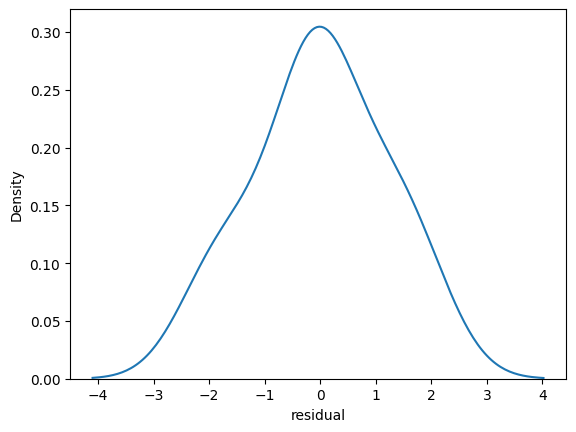

In [4]:
sns.kdeplot(quartet['residual'])

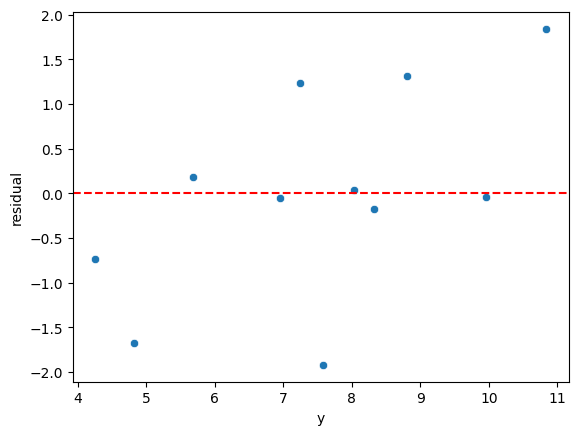

In [ ]:
# Plot de residuals tov de werkelijke y-waarden.  Is er een patroon te herkennen? 

sns.scatterplot(data=quartet, x='y', y='residual')
# voeg een horizontale lijn toe
plt.axhline(y=0, color='r', linestyle='--')

### Check nu zelf de residuals voor de **niet geschikte** datasets:

In [8]:
# Analyseer nu de residuals voor de niet geschikte datasets:
quartet2 = pd.read_csv('data/anscombes_quartet2.csv')

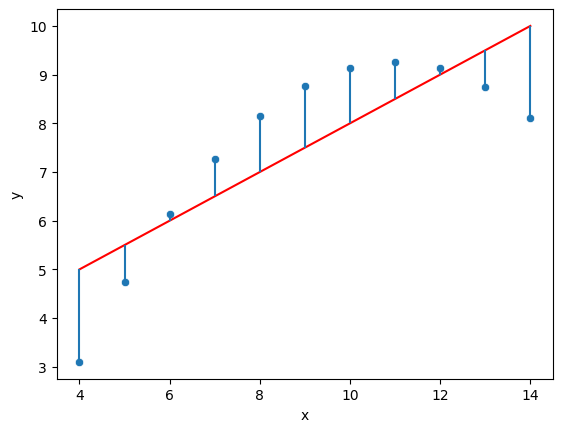

In [ ]:
quartet2['pred_y'] = 3 + 0.5 * quartet2['x']
quartet2['residual'] = quartet2['y'] - quartet2['pred_y']

sns.scatterplot(data=quartet2, x='x', y='y')
sns.lineplot(data=quartet2, x='x', y='pred_y',color='red')
plt.vlines(quartet2['x'], quartet2['y'], quartet2['y'] - quartet2['residual'])
plt.show()

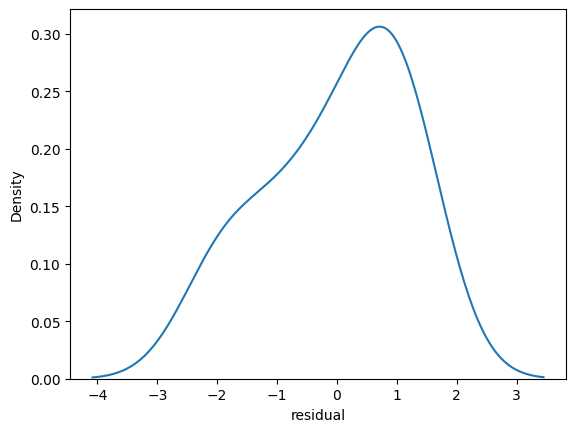

In [ ]:
# normaal verdeeld of niet?
sns.kdeplot(quartet2['residual'])
plt.show() # neen dus

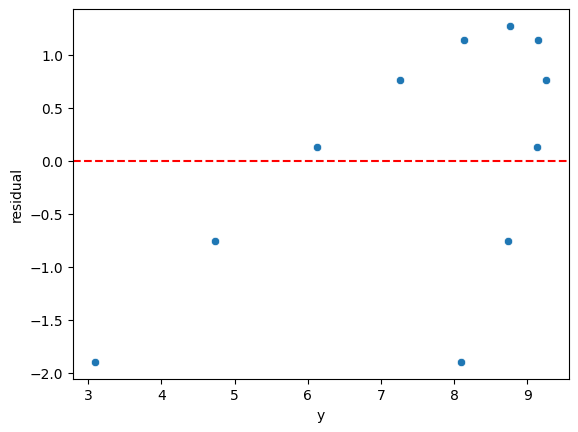

In [15]:
# residuals tov de werkelijke y-waarden.  Is er een patroon te herkennen? 

sns.scatterplot(data=quartet2, x='y', y='residual')
# voeg een horizontale lijn toe
plt.axhline(y=0, color='r', linestyle='--')
plt.show()

### En de laatste:

In [9]:
quartet4 = pd.read_csv('data/anscombes_quartet4.csv')

In [10]:
quartet4

,x,y
0,8.0,6.58
1,8.0,5.76
2,8.0,7.71
3,8.0,8.84
4,8.0,8.47
5,8.0,7.04
6,8.0,5.25
7,19.0,12.50
8,8.0,5.56
9,8.0,7.91


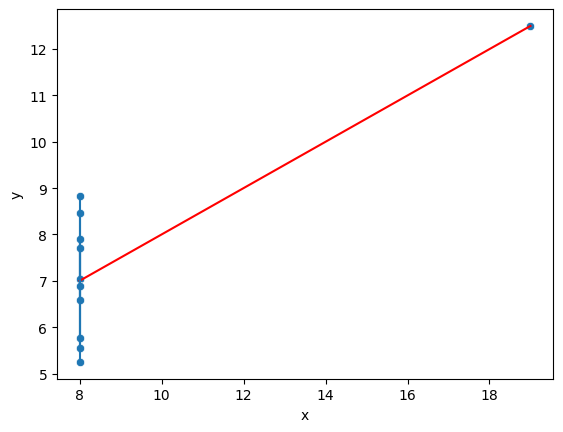

In [16]:
quartet4['pred_y'] = 3 + 0.5 * quartet4['x']
quartet4['residual'] = quartet4['y'] - quartet4['pred_y']

sns.scatterplot(data=quartet4, x='x', y='y')
sns.lineplot(data=quartet4, x='x', y='pred_y',color='red')
plt.vlines(quartet4['x'], quartet4['y'], quartet4['y'] - quartet4['residual'])
plt.show()

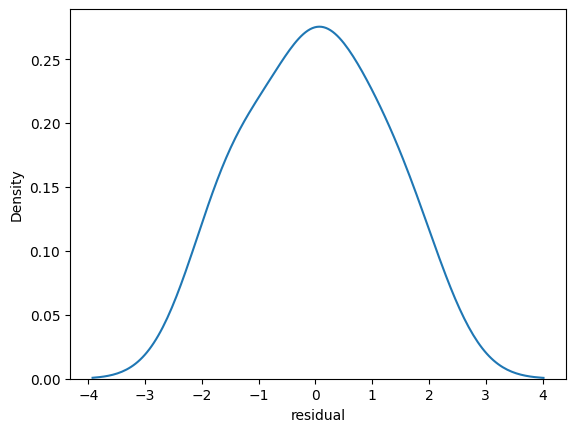

In [ ]:
# normaal verdeeld of niet?
sns.kdeplot(quartet4['residual'])
plt.show() # ja

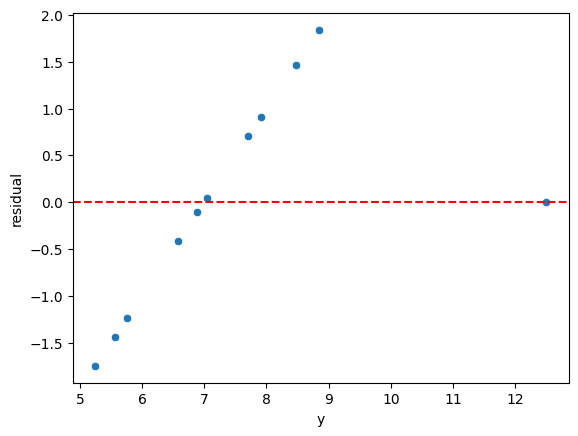

In [19]:
# residuals tov de werkelijke y-waarden.  Is er een patroon te herkennen? 

sns.scatterplot(data=quartet4, x='y', y='residual')
# voeg een horizontale lijn toe
plt.axhline(y=0, color='r', linestyle='--')
plt.show()

## Onderzoek of onze dataset met sales in functie van advertenties geschikt was voor ons lineaire regressiemodel

In [ ]:
# Bepaal de residuals op basis van de voorspellingen op de test set
test_residuals = y_test - test_pred

In [ ]:
test_residuals

In [ ]:
# Plot de residuals tov de testwaarden


In [ ]:
# Maak een distributieplot van de residuals op de test set


**Gemiddelde rond nul?**

Wat betekent het dat de plot van de residuals linksscheef verdeeld is?

In [ ]:
## Onzeker of dit normaal is verdeeld?  We kunnen dit aftoetsen tegenover een normal probability plot.  Deze geeft  
import scipy as sp

In [ ]:
# Maak een figure en ax om op te plotten
fig, ax = plt.subplots(figsize=(6,8),dpi=100)
# probplot geeft de ruwe waarden.  Deze gebruiken we niet, dus we kennen ze toe aan _
_ = sp.stats.probplot(test_residuals,plot=ax)

# Deployen van het model

## Trainen van het model op de volledige dataset

## Opslaan en opnieuw laden van een model

In [ ]:
# Nieuwe modelinstance "final__model" maken:


In [ ]:
# Fitten van het model op alle data:


Aangezien het model alle data heeft gezien, heeft het weinig zin om vb RMSE te herberekenen - we moeten ons baseren op de waarden die we voorheen hebben berekend!

In [ ]:
# Coëfficiënten van het model


## Plot voorspellingen tov echte y labels

In [ ]:
y_hat =  

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(16,6))

# plot TV vs Sales - de "echte" y labels
axes[0].plot(df['TV'], df['sales'],'o')
# plot de voorspelde sales
axes[0].plot(df['TV'], y_hat,'o', color='red')
axes[0].set_ylabel("Sales")
axes[0].set_title("TV Spend")

# plot radio vs Sales
axes[1].plot(df['radio'], df['sales'],'o')
axes[1].plot(df['radio'], y_hat,'o', color='red')
axes[1].set_ylabel("Sales")
axes[1].set_title("Radio Spend")

# plot newspaper vs Sales
axes[2].plot(df['newspaper'], df['sales'],'o')
axes[2].plot(df['newspaper'], y_hat,'o', color='red')
axes[2].set_ylabel("Sales")
axes[2].set_title("Newspaper Spend")

# saven en opnieuw laden van het model

In [ ]:
from joblib import dump, load

In [ ]:
dump(final_model, 'final_sales_model.joblib')

In [ ]:
loaded_model = load('final_sales_model.joblib')

In [ ]:
loaded_model.coef_

### Finale test: voorspellen van de sales waarde voor een nieuwe campagne

In [ ]:
# voorspel de sales voor een campagne met 149 TV,  22 radio, en 12 newspaper
